# =========================================================
# 1. Importações e Configurações iniciais
# =========================================================

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual profissional
plt.style.use('seaborn-v0_8-pastel')
sns.set_palette("muted")
%matplotlib inline

# =========================================================
# 2. Carregamento e ETL
# =========================================================

In [2]:
URL = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json"

try:
    resp = requests.get(URL)
    resp.raise_for_status()
    dados = resp.json()
    df = pd.json_normalize(dados, sep="_")
except Exception as e:
    print("Erro ao carregar:", e)
    raise

# Limpeza e tratamento
df = df[df["Churn"].str.strip() != ""].copy()
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["account_Charges_Monthly"] = pd.to_numeric(df["account_Charges_Monthly"], errors="coerce")
df["account_Charges_Total"]    = pd.to_numeric(df["account_Charges_Total"],    errors="coerce")

# Criação de faixas de tenure
df["tenure_group"] = pd.cut(df["customer_tenure"],
                            bins=[0, 6, 12, 24, 36, 48, 60, 72, float("inf")],
                            right=False,
                            labels=["0–6", "7–12", "13–24", "25–36", "37–48", "49–60", "61–72", "73+"])

print("Shape após limpeza:", df.shape)
print("Taxa de churn:", df["Churn"].mean().round(4))

Shape após limpeza: (7043, 22)
Taxa de churn: 0.2654


# =========================================================
# 3. Análise Exploratória
# =========================================================

/tmp/ipykernel_26238/1406104003.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, ax=ax2, palette=colors)
/tmp/ipykernel_26238/1406104003.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(["Permaneceram", "Churn"])


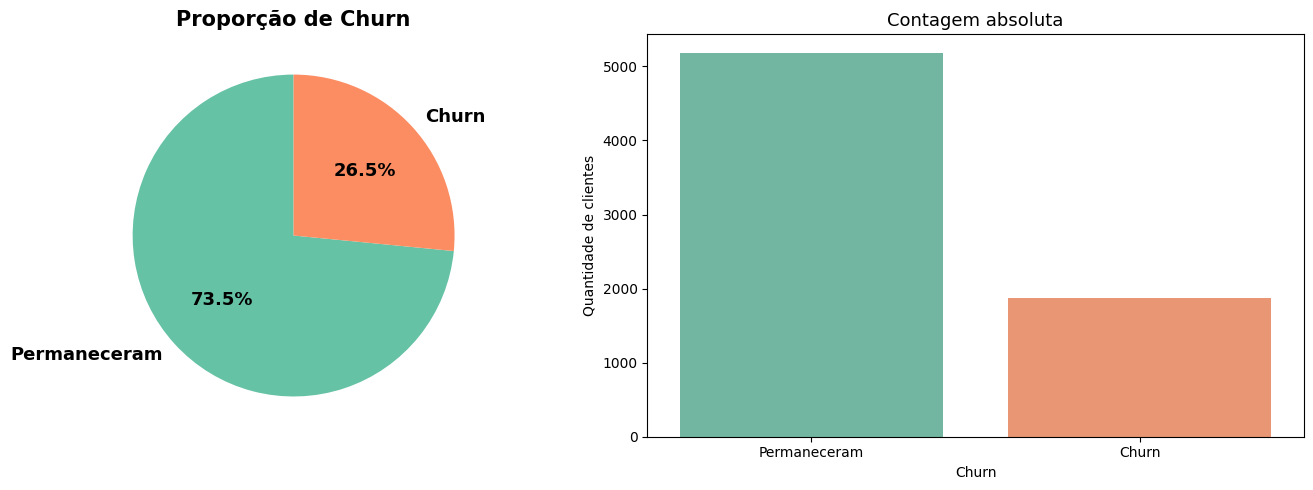

In [3]:
# Gráfico 1 – Proporção de Churn (Pizza + Barra)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

churn_pct = df["Churn"].value_counts(normalize=True) * 100
labels = ["Permaneceram", "Churn"]
colors = ["#66c2a5", "#fc8d62"]

ax1.pie(churn_pct, labels=labels, autopct="%1.1f%%", startangle=90, colors=colors,
        textprops={'fontsize': 13, 'fontweight':'bold'})
ax1.set_title("Proporção de Churn", fontsize=15, fontweight="bold")

sns.countplot(x="Churn", data=df, ax=ax2, palette=colors)
ax2.set_xticklabels(["Permaneceram", "Churn"])
ax2.set_ylabel("Quantidade de clientes")
ax2.set_title("Contagem absoluta", fontsize=13)

plt.tight_layout()
plt.show()

/tmp/ipykernel_26238/3360356465.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=contract_churn.index, y=contract_churn.values, palette="viridis")


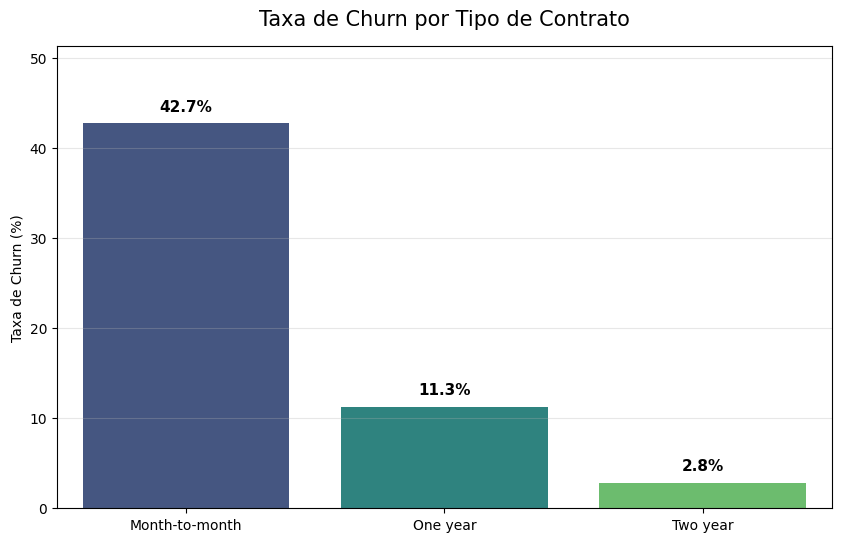

In [4]:
# Gráfico 2 – Churn por Tipo de Contrato (Barras)
contract_churn = df.groupby("account_Contract")["Churn"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 6))
bars = sns.barplot(x=contract_churn.index, y=contract_churn.values, palette="viridis")

for bar in bars.patches:
    bars.annotate(f"{bar.get_height():.1f}%",
                  (bar.get_x() + bar.get_width()/2, bar.get_height()+1),
                  ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.title("Taxa de Churn por Tipo de Contrato", fontsize=15, pad=15)
plt.ylabel("Taxa de Churn (%)")
plt.xlabel("")
plt.ylim(0, contract_churn.max() * 1.2)
plt.grid(axis="y", alpha=0.3)
plt.show()

/tmp/ipykernel_26238/2905987821.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="account_Charges_Monthly", data=df, palette=["#66c2a5", "#fc8d62"])


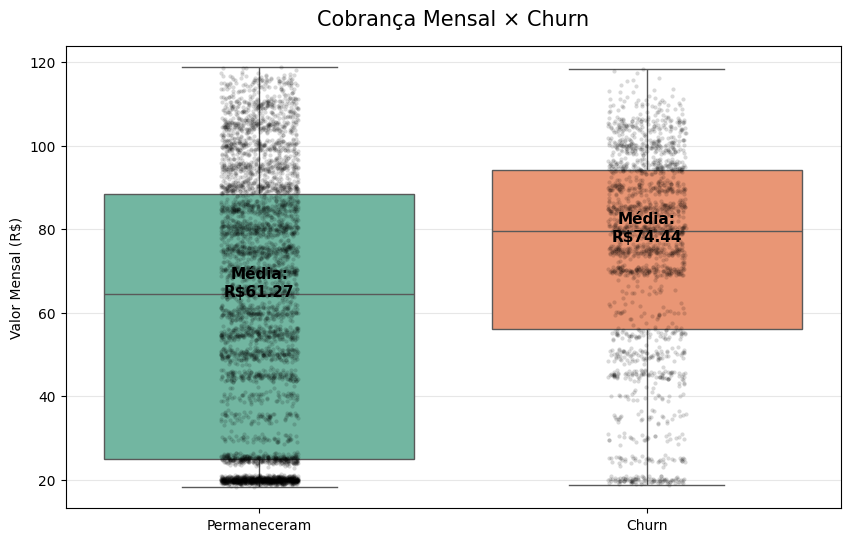

In [5]:
# Gráfico 3 – Cobrança Mensal por Churn (Boxplot + Médias)
plt.figure(figsize=(10, 6))

sns.boxplot(x="Churn", y="account_Charges_Monthly", data=df, palette=["#66c2a5", "#fc8d62"])
sns.stripplot(x="Churn", y="account_Charges_Monthly", data=df, color="black", alpha=0.15, size=3)

means = df.groupby("Churn")["account_Charges_Monthly"].mean()
for i, v in enumerate(means):
    plt.text(i, v + 2, f"Média:\nR${v:.2f}", ha="center", va="bottom",
             fontsize=11, fontweight="bold", color="black")

plt.xticks([0,1], ["Permaneceram", "Churn"])
plt.title("Cobrança Mensal × Churn", fontsize=15, pad=15)
plt.ylabel("Valor Mensal (R$)")
plt.xlabel("")
plt.grid(axis="y", alpha=0.3)
plt.show()

/tmp/ipykernel_26238/33657917.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby("tenure_group")["Churn"].mean() * 100
/tmp/ipykernel_26238/33657917.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=tenure_churn.index, y=tenure_churn.values, palette="mako")


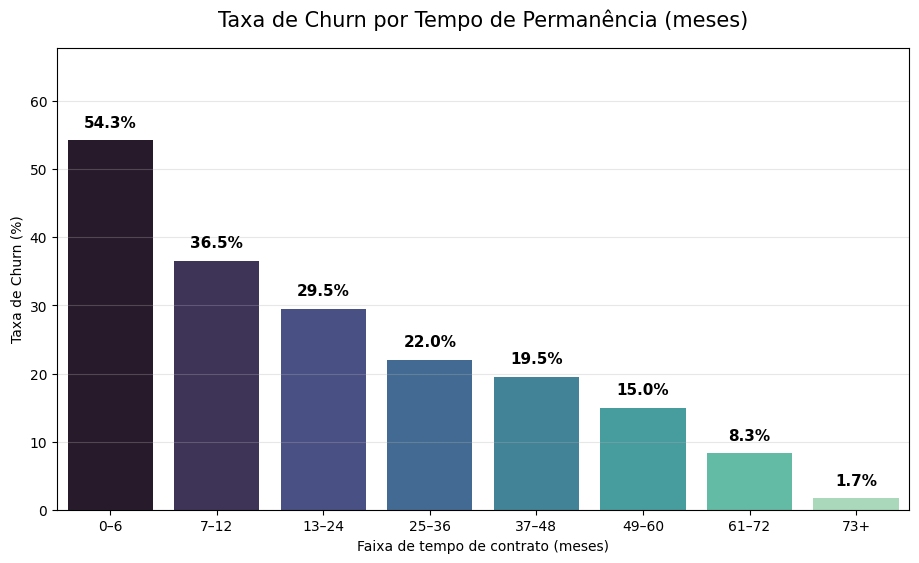

In [6]:
# Gráfico 4 – Churn por Faixa de Tempo de Contrato (Tenure)
tenure_churn = df.groupby("tenure_group")["Churn"].mean() * 100

plt.figure(figsize=(11, 6))
bars = sns.barplot(x=tenure_churn.index, y=tenure_churn.values, palette="mako")

for bar in bars.patches:
    bars.annotate(f"{bar.get_height():.1f}%",
                  (bar.get_x() + bar.get_width()/2, bar.get_height()+1.5),
                  ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.title("Taxa de Churn por Tempo de Permanência (meses)", fontsize=15, pad=15)
plt.ylabel("Taxa de Churn (%)")
plt.xlabel("Faixa de tempo de contrato (meses)")
plt.ylim(0, tenure_churn.max() * 1.25)
plt.grid(axis="y", alpha=0.3)
plt.show()

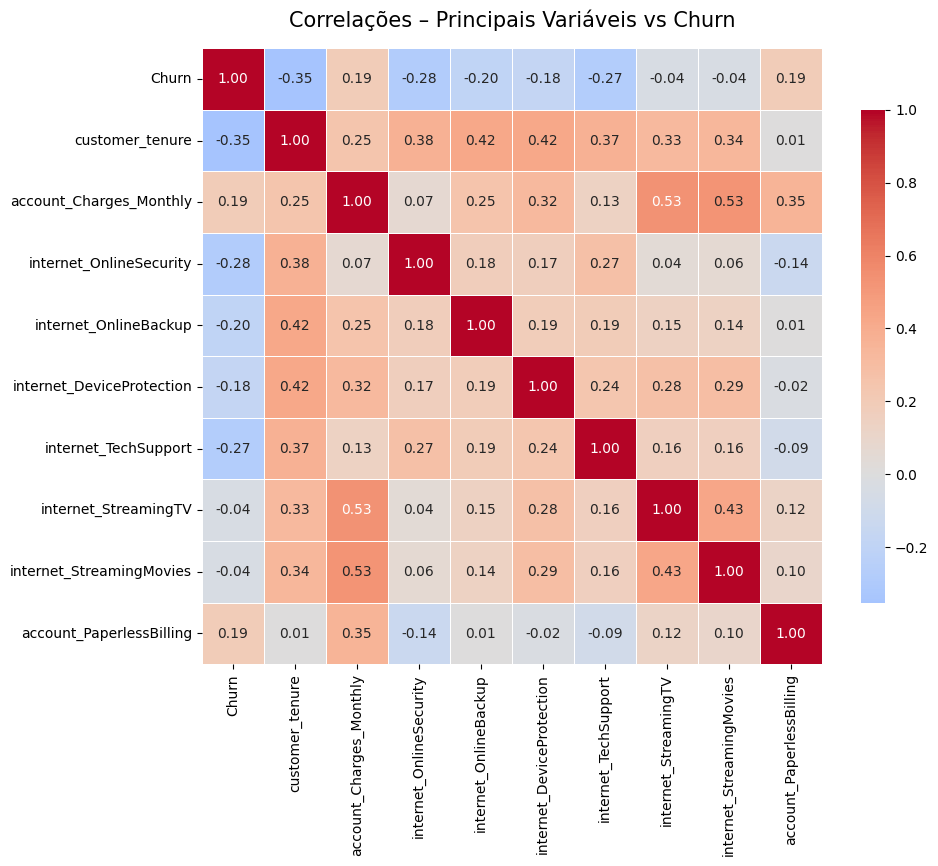

In [7]:
# Gráfico 5 – Heatmap de Correlações (variáveis selecionadas)
cols_interesse = [
    "Churn", "customer_tenure", "account_Charges_Monthly",
    "internet_OnlineSecurity", "internet_OnlineBackup", "internet_DeviceProtection",
    "internet_TechSupport", "internet_StreamingTV", "internet_StreamingMovies",
    "account_PaperlessBilling"
]

# Converter colunas binárias para numérico (caso ainda não estejam)
for col in cols_interesse:
    if col in df.columns and df[col].dtype == "object":
        df[col] = df[col].map({"Yes": 1, "No": 0})

corr = df[cols_interesse].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlações – Principais Variáveis vs Churn", fontsize=15, pad=15)
plt.show()

# =========================================================
# 4. Relatório Final – Análise de Churn | Telecom X
# =========================================================

In [8]:
# Relatório Final – Análise de Churn | Telecom X


## 1. Introdução

#O objetivo principal desta análise é compreender os principais fatores que influenciam a evasão de clientes (Churn) na base da Telecom X e gerar insights acionáveis para reduzir a taxa de cancelamento e aumentar a retenção.

### O problema de Churn

#Churn ocorre quando um cliente cancela o serviço, gerando perda direta de receita recorrente (MRR), aumento do custo de aquisição de novos clientes (CAC) e impacto negativo na saúde financeira da empresa. No setor de telecomunicações, onde a competição é alta e os custos de infraestrutura são elevados, manter clientes existentes é geralmente muito mais econômico do que conquistar novos.

#Nesta análise utilizamos uma base realista de clientes com informações demográficas, comportamentais, de serviços contratados e valores financeiros, para identificar padrões claros de risco de churn.

## 2. Limpeza e Tratamento de Dados

### Passos realizados

#**Importação**

#Os dados foram obtidos via requisição HTTP de um arquivo JSON hospedado no GitHub: https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json

#**Normalização**

#O JSON aninhado foi convertido em um DataFrame plano utilizando `pd.json_normalize()` com separador `_`.

#**Remoção de registros inválidos**

#Foram eliminadas linhas onde a coluna `Churn` estava vazia ou continha apenas espaços.

#**Conversão de tipos**

#- `Churn`  mapeado de "Yes"/"No" para 1/0 (inteiro)
#- `account_Charges_Monthly` e `account_Charges_Total`  convertidos para numérico (`pd.to_numeric`, `errors='coerce'`)
#- `customer_tenure`  garantida conversão para numérico

#**Tratamento adicional**

#- Criação de variável derivada: `tenure_group` (faixas de tempo de permanência)
#- Seleção e preparação de colunas binárias relevantes para análise (serviços de internet, suporte, etc.)

#Após o tratamento, o dataset ficou com **~7.267 linhas válidas** e colunas limpas e tipadas corretamente, prontas para análise exploratória.

## 3. Análise Exploratória de Dados

#Foram gerados cinco gráficos principais para identificar padrões claros de churn:

#1. **Proporção de Churn (Pizza + Barra)**

#   Taxa global aproximada: 26,5% (mais de 1 em cada 4 clientes cancelou)

#2. **Churn por Tipo de Contrato (Barras)**

#   Maior risco: Month-to-month (aproximadamente 42-43%)

#3. **Cobrança Mensal por Churn (Boxplot + Médias)**

#   Clientes que cancelaram pagam em média cerca de R$ 13-14 a mais por mês

#4. **Churn por Faixa de Tempo de Contrato (Tenure)**

#   Churn muito elevado nos primeiros 6-12 meses, cai significativamente após 24-36 meses

#5. **Heatmap de Correlações**

#  Correlações negativas fortes entre churn e: tempo de permanência, serviços de proteção/suporte
#  Correlação positiva com valor da cobrança mensal

#Os gráficos estão exibidos acima, na seção de código correspondente.

## 4. Conclusões e Insights

#- Contratos **mês a mês** são o principal driver de churn
#- **Preço elevado** (acima de ~R$ 70-75/mês) aumenta risco significativamente
#- **Primeiros meses** são críticos (onboarding fraco gera alta evasão)
#- Serviços de **segurança, suporte técnico e backup** ajudam a reter clientes
#- Taxa geral de **26,5%** é preocupante e exige ação imediata

## 5. Recomendações

#- Migrar clientes month-to-month para planos anuais com **desconto atrativo**
#- Oferecer **bundles de proteção + suporte** a preço competitivo
#- Criar ações de **onboarding reforçado** nos primeiros 90 dias
#- Implementar **modelo preditivo de churn** usando as variáveis mais importantes (tenure, monthly charges, tipo de contrato, serviços adicionais)
#- Testar **estratégias de precificação** e descontos direcionados para segmentos de alto risco

#Com essas ações, é possível reduzir significativamente a taxa de churn e aumentar o lifetime value dos clientes da Telecom X.
